# Credit Card Fraud Detection — EDA

## Dataset
- Source: Kaggle (ULB Machine Learning Group)
- 284,807 transactions | 31 features | 0 missing values

## Key Findings
1. **Severe class imbalance** — only 0.17% of transactions are fraud (492 out of 284,807)
2. **Fraud transactions cluster at lower amounts** — fraudsters avoid triggering large-transaction alerts
3. **Time patterns differ** — fraud spikes at off-peak hours compared to legitimate transactions

## Next Step
Week 2 — Apply SMOTE to handle imbalance, then train Logistic Regression, Random Forest, and XGBoost models

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/creditcard.csv')

print(df.shape)        # (284807, 31)
print(df.dtypes)
print(df.isnull().sum())  # Check missing values
print(df.describe())

(284807, 31)
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
                Time          

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


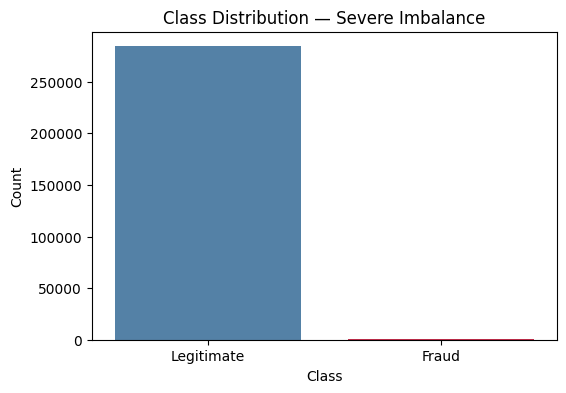

In [5]:
fraud_count = df['Class'].value_counts()
fraud_pct = df['Class'].value_counts(normalize=True) * 100

print(fraud_count)
print(fraud_pct)

# Visualize
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df, hue='Class', legend=False,
              palette=['steelblue','crimson'])
plt.title('Class Distribution — Severe Imbalance')
plt.xticks([0,1], ['Legitimate', 'Fraud'])
plt.ylabel('Count')
plt.savefig('../reports/class_distribution.png', dpi=150)
plt.show()

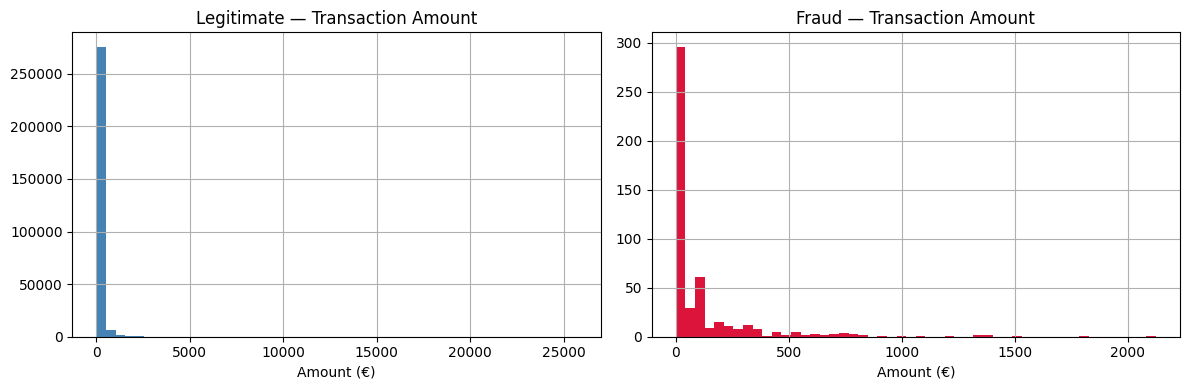

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[df['Class']==0]['Amount'].hist(bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Legitimate — Transaction Amount')
axes[0].set_xlabel('Amount (€)')

df[df['Class']==1]['Amount'].hist(bins=50, ax=axes[1], color='crimson')
axes[1].set_title('Fraud — Transaction Amount')
axes[1].set_xlabel('Amount (€)')

plt.tight_layout()
plt.savefig('../reports/amount_distribution.png', dpi=150)
plt.show()

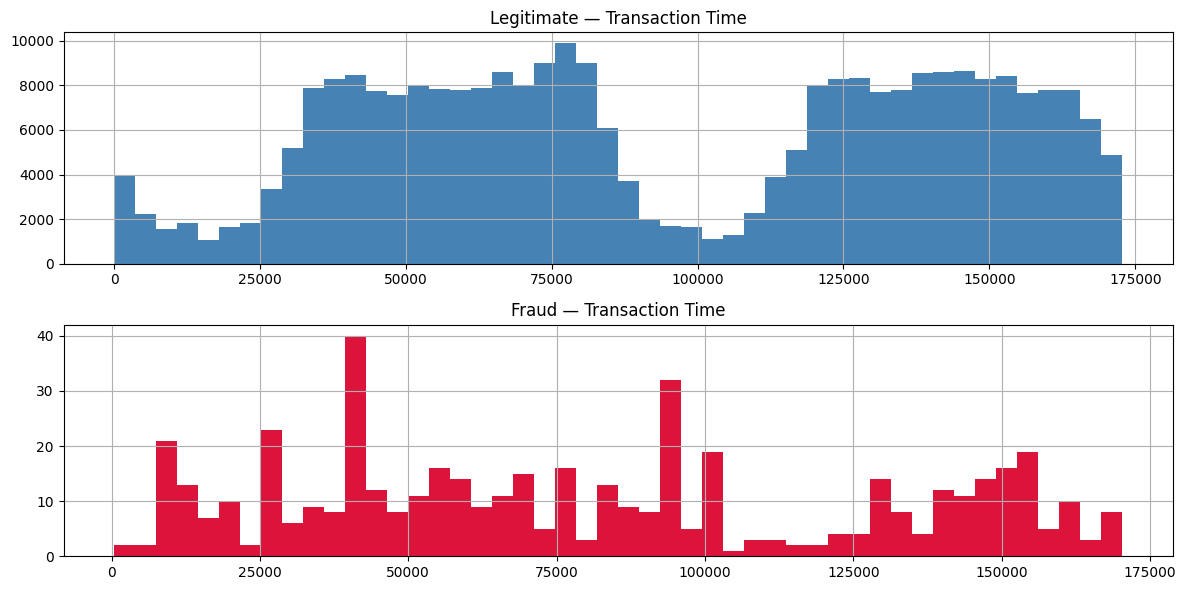

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

df[df['Class']==0]['Time'].hist(bins=48, ax=axes[0], color='steelblue')
axes[0].set_title('Legitimate — Transaction Time')

df[df['Class']==1]['Time'].hist(bins=48, ax=axes[1], color='crimson')
axes[1].set_title('Fraud — Transaction Time')

plt.tight_layout()
plt.savefig('../reports/time_distribution.png', dpi=150)
plt.show()

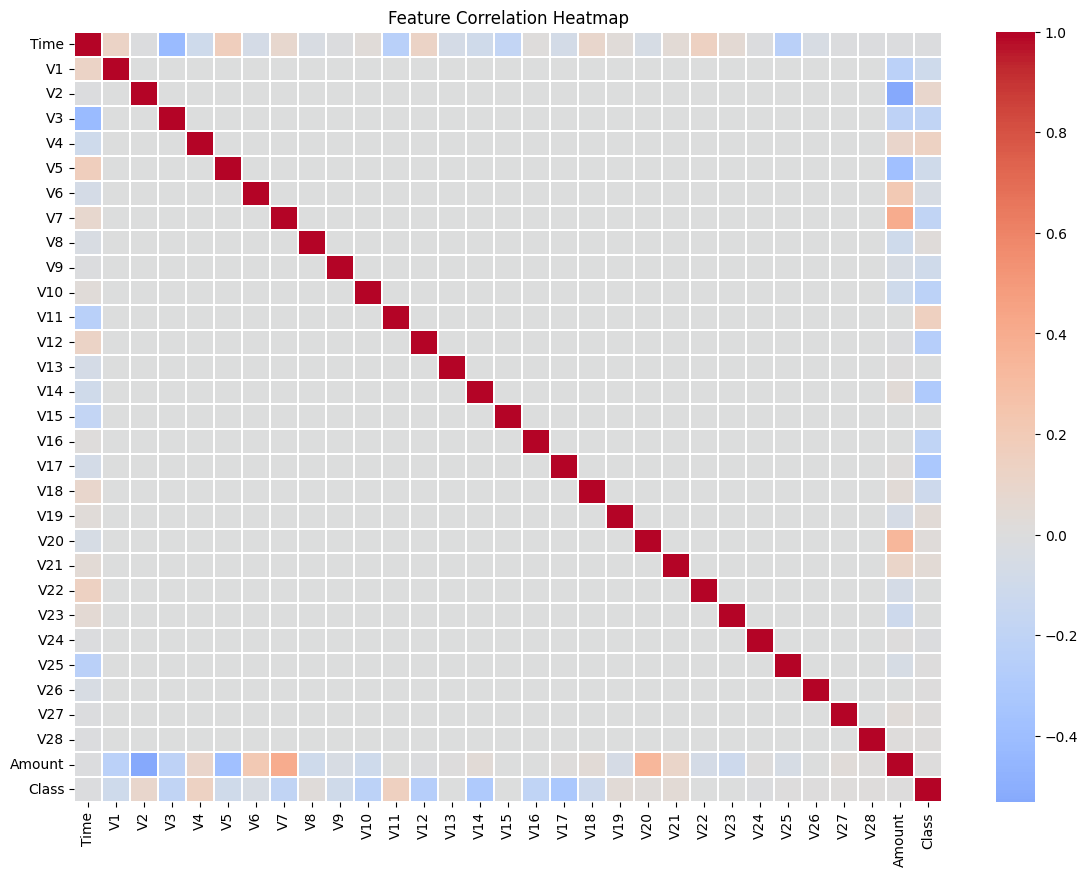

In [8]:
plt.figure(figsize=(14, 10))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0,
            linewidths=0.3, annot=False)
plt.title('Feature Correlation Heatmap')
plt.savefig('../reports/correlation_heatmap.png', dpi=150)
plt.show()